In [ ]:
import numpy as np
import pandas as pd
from scipy import stats ### for stats description for A/B test
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Basic preview
df = pd.read_csv('marketing_AB.csv')
last5_rows = df.iloc[-5:]
print(last5_rows)

        Unnamed: 0  user id test group  converted  total ads most ads day  \
588096      588096  1278437         ad      False          1      Tuesday   
588097      588097  1327975         ad      False          1      Tuesday   
588098      588098  1038442         ad      False          3      Tuesday   
588099      588099  1496395         ad      False          1      Tuesday   
588100      588100  1237779         ad      False          1      Tuesday   

        most ads hour  
588096             23  
588097             23  
588098             23  
588099             23  
588100             23  


In [ ]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
#Basic preview
df = pd.read_csv('marketing_AB.csv')
last5_rows = df.iloc[-5:]
print(last5_rows)

        Unnamed: 0  user id test group  converted  total ads most ads day  \
588096      588096  1278437         ad      False          1      Tuesday   
588097      588097  1327975         ad      False          1      Tuesday   
588098      588098  1038442         ad      False          3      Tuesday   
588099      588099  1496395         ad      False          1      Tuesday   
588100      588100  1237779         ad      False          1      Tuesday   

        most ads hour  
588096             23  
588097             23  
588098             23  
588099             23  
588100             23  


In [ ]:
#Define rows where are missing value
rows_with_empty_values = df[df.isnull().any(axis=1)]
display(rows_with_empty_values)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour


In [ ]:
#data type of each column
df.dtypes

,0
Unnamed: 0,int64
user id,int64
test group,object
converted,bool
total ads,int64
most ads day,object
most ads hour,int64


In [ ]:
#number of nulls in data
df.isna().sum()

,0
Unnamed: 0,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


In [ ]:
#Working with basic statistics values for the dataset
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [ ]:
#Unique values for the categorical records
print('test group_unique_v', df['test group'].unique())
print('converted', df['converted'].unique())
print('most ads day', df['most ads day'].unique())
print('most ads hour', df['most ads hour'].unique())

test group_unique_v ['ad' 'psa']
converted [False  True]
most ads day ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']
most ads hour [20 22 18 10 14 13 19 11 12 16 21  3 23  4  8  0  2 15  1  6 17  7  9  5]


In [ ]:
# Test Group Analysis
control = df[df['test group'] == 'psa']
treatment = df[df['test group'] == 'ad']
t_stat, p_val = stats.ttest_ind(treatment['converted'], control['converted'])
print(f"Test Group Analysis - T-statistic: {t_stat}, P-value: {p_val}")

Test Group Analysis - T-statistic: 7.37040597428566, P-value: 1.7033052627831264e-13


Interpretation of statistical results for A/B testing:
P-value: 1.7033 × 10^(−13), which is equal to: 0.00000000000017033. This is lower than the industry standard of 0.05. Therefore, the null hypothesis must be rejected.
The result is highly statistically significant. The difference measured between the 'ad' and 'psa' conversion rates is not due to random chance. This data could inform business decisions.

T-statistic interpretation: Direction and strength.
The T-statistic of 7.37040597428566 is a very high coefficient that the data for this test is reliable, and that the difference between the control and treatment groups that converted is significant.

In [ ]:
#Calculation of Conversion rate according to the group
df.groupby('test group')['converted'].mean()


,converted
test group,
ad,0.025547
psa,0.017854


/tmp/ipython-input-802441858.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


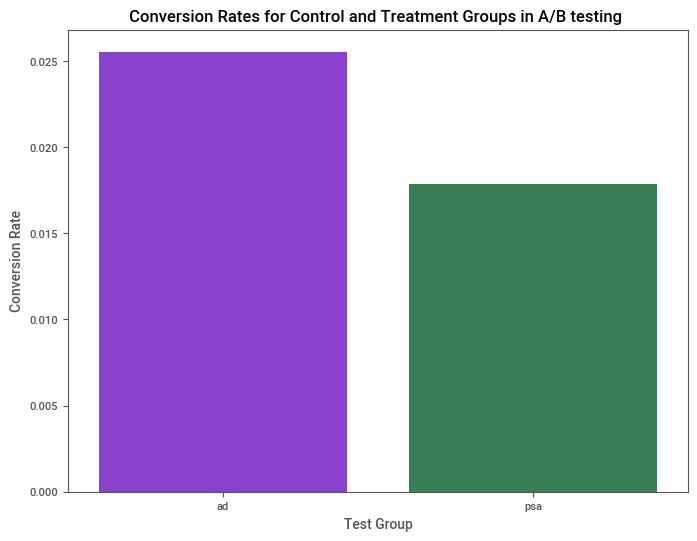

In [ ]:
# 1. Calculate the Conversion Rates
conversion_rates = df.groupby('test group')['converted'].mean().reset_index()
conversion_rates.columns = ['Test Group', 'Conversion Rate']

# 2. Define the Custom Color Palette (MUST be defined before it's used)
custom_palette = {
    'ad': 'blueviolet',  # Violet for the treatment group
    'psa': 'seagreen'     # Green for the control group
}

# 3. Initialize the Plot Figure
plt.figure(figsize=(8, 6))

# 4. Create the Bar Chart
sns.barplot(
    x='Test Group',
    y='Conversion Rate',
    data=conversion_rates,
    palette=custom_palette # <-- Correctly using the defined palette
)

# 5. Set Title and Labels (Must be called after the plot is created)
plt.title('Conversion Rates for Control and Treatment Groups in A/B testing ')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate')

# 6. Display the Plot
plt.show()

In [ ]:
conversion_rates = df.groupby('test group')['converted'].mean()
diff_conversion_rate = conversion_rates['ad'] - conversion_rates['psa']
print(f"Difference in conversion rate (ad - psa): {diff_conversion_rate:.4f}")

Difference in conversion rate (ad - psa): 0.0077


In [ ]:
add correlation analysis between day and conversion
add correlation analysis between hour and conversion